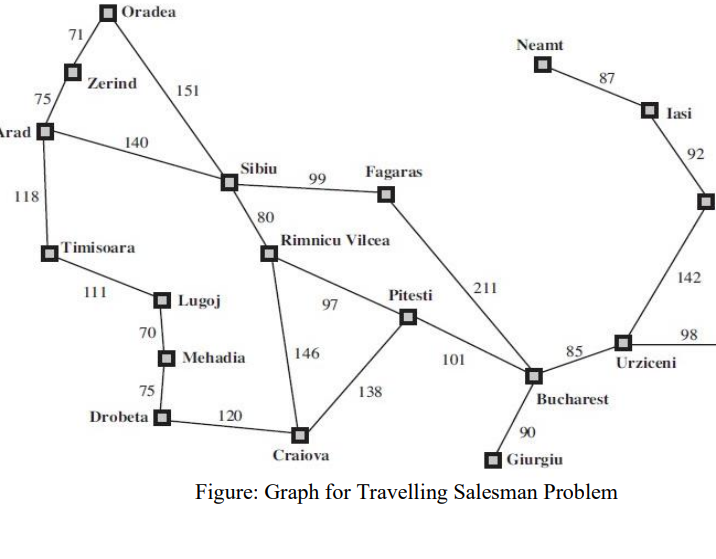

In [4]:
graph = {
    'Arad': [('Zerind',75), ('Timisoara',118), ('Sibiu',140)],
    'Zerind': [('Oradea',71), ('Arad',75)],
    'Oradea': [('Sibiu',151), ('Zerind',71)],
    'Timisoara': [('Lugoj',111), ('Arad',118)],
    'Lugoj': [('Mehadia',70), ('Timisoara',111)],
    'Mehadia': [('Drobeta',75), ('Lugoj',70)],
    'Drobeta': [('Craiova',120), ('Mehadia',75)],
    'Craiova': [('Pitesti',138), ('Rimnicu Vilcea',146), ('Drobeta',120)],
    'Sibiu': [('Fagaras',99), ('Rimnicu Vilcea',80), ('Arad',140)],
    'Rimnicu Vilcea': [('Pitesti',97), ('Craiova',146), ('Sibiu',80)],
    'Fagaras': [('Bucharest',211), ('Sibiu',99)],
    'Pitesti': [('Bucharest',101), ('Rimnicu Vilcea',97), ('Craiova',138)],
    'Bucharest': []
}

visited = set()

def dfs(node, goal, path, cost):
    path.append(node)

    if node == goal:
        return path, cost

    visited.add(node)

    for neighbour, distance in graph[node]:
        if neighbour not in visited:
            result = dfs(neighbour, goal, path.copy(), cost + distance)
            if result:
                return result

    return None

start = 'Arad'
goal = 'Bucharest'

result = dfs(start, goal, [], 0)

if result:
    print("Path:", " → ".join(result[0]))
    print("Total Distance:", result[1])
else:
    print("No path found")

Path: Arad → Zerind → Oradea → Sibiu → Fagaras → Bucharest
Total Distance: 607


In [5]:
# ---------------- Lab Task 2 Demo ----------------
from collections import deque

# Graph (Romania Map)
graph = {
    'Arad': [('Zerind',75), ('Timisoara',118), ('Sibiu',140)],
    'Zerind': [('Oradea',71)],
    'Oradea': [('Sibiu',151)],
    'Timisoara': [('Lugoj',111)],
    'Lugoj': [('Mehadia',70)],
    'Mehadia': [('Drobeta',75)],
    'Drobeta': [('Craiova',120)],
    'Craiova': [('Pitesti',138)],
    'Sibiu': [('Fagaras',99), ('Rimnicu Vilcea',80)],
    'Rimnicu Vilcea': [('Pitesti',97)],
    'Fagaras': [('Bucharest',211)],
    'Pitesti': [('Bucharest',101)],
    'Bucharest': []
}

# -------- DFS --------
def dfs(node, goal, visited, path):
    visited.add(node)
    path.append(node)

    if node == goal:
        return path

    for neighbour, _ in graph[node]:
        if neighbour not in visited:
            result = dfs(neighbour, goal, visited, path.copy())
            if result:
                return result
    return None

# -------- BFS --------
def bfs(start, goal):
    visited = set()
    queue = deque([[start]])

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbour, _ in graph[node]:
                new_path = list(path)
                new_path.append(neighbour)
                queue.append(new_path)
    return None

# -------- Case 1 --------
print("Case 1: BFS visits fewer nodes than DFS")
print("Start: Arad → Goal: Sibiu")

print("DFS Path:", dfs('Arad', 'Sibiu', set(), []))
print("BFS Path:", bfs('Arad', 'Sibiu'))

# -------- Case 2 --------
print("\nCase 2: DFS visits fewer nodes than BFS")
print("Start: Arad → Goal: Timisoara")

print("DFS Path:", dfs('Arad', 'Timisoara', set(), []))
print("BFS Path:", bfs('Arad', 'Timisoara'))

Case 1: BFS visits fewer nodes than DFS
Start: Arad → Goal: Sibiu
DFS Path: ['Arad', 'Zerind', 'Oradea', 'Sibiu']
BFS Path: ['Arad', 'Sibiu']

Case 2: DFS visits fewer nodes than BFS
Start: Arad → Goal: Timisoara
DFS Path: ['Arad', 'Timisoara']
BFS Path: ['Arad', 'Timisoara']
